# Backbone Feature 추출 & 시각화

DINOv3 backbone만 통과한 feature map을 뽑고 시각화하는 예제입니다.

- **출력 shape**: `[B, 384, H', W']` — `H' = W' = image_size / 16` (patch size 16)
  - 384 입력 → 24×24 / **768 입력 → 48×48** / 1536 입력 → 96×96
- **방법 1**: 단일 이미지에서 `model.encode()` 로 live 추출
- **방법 2**: `cache_features.py` 로 저장된 shard(`.pt`) 읽기

> `dfu-project/example/` 에서 실행하세요. 아래 셀이 프로젝트 루트를 `sys.path`에 추가합니다.

In [7]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image

# example/ → dfu-project 루트
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "example":
    PROJECT_ROOT = PROJECT_ROOT.parent
elif not (PROJECT_ROOT / "models").exists():
    PROJECT_ROOT = PROJECT_ROOT / "01_개발" / "dfu-project"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from inference.pipeline import preprocess_image
from models import MultiTaskSegModel
from paths import DATA_ROOT, FEATURE_CACHE_DIR, TRAIN_OUTPUT_DIR
from utils.runtime import resolve_device

PATCH_SIZE = 16
# backbone feature 격자: image_size / 16 (768 → 48×48, 1536 → 96×96)
IMAGE_SIZE = 768
DISPLAY_SIZE = 768  # 시각화용 업샘플 크기

DEVICE = resolve_device("auto")
print(f"project:       {PROJECT_ROOT}")
print(f"device:        {DEVICE}")
print(f"feature grid:  {IMAGE_SIZE // PATCH_SIZE}×{IMAGE_SIZE // PATCH_SIZE}  (input {IMAGE_SIZE})")

project:       /mnt/d/ysla/01_Work/02_당뇨발/01_개발/dfu-project
device:        cuda
feature grid:  48×48  (input 768)


## 1. 단일 이미지에서 backbone feature 추출

`model.encode()` 로 backbone만 실행합니다. (foot/ulcer head는 거치지 않음)

입력 해상도를 올리면 feature map 격자도 촘촘해집니다. `IMAGE_SIZE` 는 16의 배수여야 합니다.

In [8]:
def find_sample_image() -> Path:
    candidates = [
        DATA_ROOT / "Testing" / "Testing" / "Diabetic Foot Ulcer 1.png",
        PROJECT_ROOT / "output" / "inference",
    ]
    for candidate in candidates:
        if candidate.is_file():
            return candidate
        if candidate.is_dir():
            for pattern in ("*.jpg", "*.jpeg", "*.png", "*.webp"):
                matches = sorted(candidate.glob(pattern))
                if matches:
                    return matches[0]
    raise FileNotFoundError(
        "샘플 이미지를 찾지 못했습니다. IMAGE_PATH 를 직접 지정하세요."
    )


def find_checkpoint() -> Path:
    candidates = [
        PROJECT_ROOT / "checkpoints" / "best.pt",
        TRAIN_OUTPUT_DIR / "20260616_161143" / "best.pt",
    ]
    for path in candidates:
        if path.exists():
            return path
    runs = sorted(TRAIN_OUTPUT_DIR.glob("*/best.pt")) if TRAIN_OUTPUT_DIR.exists() else []
    if runs:
        return runs[-1]
    raise FileNotFoundError("체크포인트를 찾지 못했습니다. CHECKPOINT 를 직접 지정하세요.")


IMAGE_PATH = find_sample_image()  # 필요 시 Path("/path/to/image.jpg") 로 교체
CHECKPOINT = find_checkpoint()    # 필요 시 직접 지정

payload = torch.load(CHECKPOINT, map_location="cpu", weights_only=False)
model = MultiTaskSegModel()
model.load_state_dict(payload["model"])
model = model.to(DEVICE).eval()

image = Image.open(IMAGE_PATH).convert("RGB")
input_tensor = preprocess_image(image, IMAGE_SIZE, DEVICE)

with torch.inference_mode():
    features = model.encode(input_tensor)  # backbone only

grid = IMAGE_SIZE // PATCH_SIZE
print(f"image:     {IMAGE_PATH}")
print(f"checkpoint:{CHECKPOINT}")
print(f"input:     {tuple(input_tensor.shape)}")
print(f"features:  {tuple(features.shape)} {features.dtype}")
print(f"grid:      {grid}×{grid}  (24×24 at image_size=384)")
print(f"stats:     min={features.min():.4f} max={features.max():.4f} mean={features.mean():.4f}")

image:     /mnt/d/ysla/01_Work/02_당뇨발/03_데이터/Testing/Testing/Diabetic Foot Ulcer 1.png
checkpoint:/mnt/d/ysla/01_Work/02_당뇨발/01_개발/dfu-project/checkpoints/best.pt
input:     (1, 3, 768, 768)
features:  (1, 384, 48, 48) torch.float32
grid:      48×48  (24×24 at image_size=384)
stats:     min=-2.7710 max=3.6306 mean=-0.0024


## 2. 시각화

384채널 feature map은 채널 평균·PCA로 2D로 줄인 뒤, `DISPLAY_SIZE`까지 업샘플해 표시합니다.

- native 격자: `IMAGE_SIZE / 16` (기본 768 → **48×48**)
- 더 촘촘히: 첫 셀에서 `IMAGE_SIZE = 1536` (96×96, VRAM 주의)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.00087921973..1.0015242].


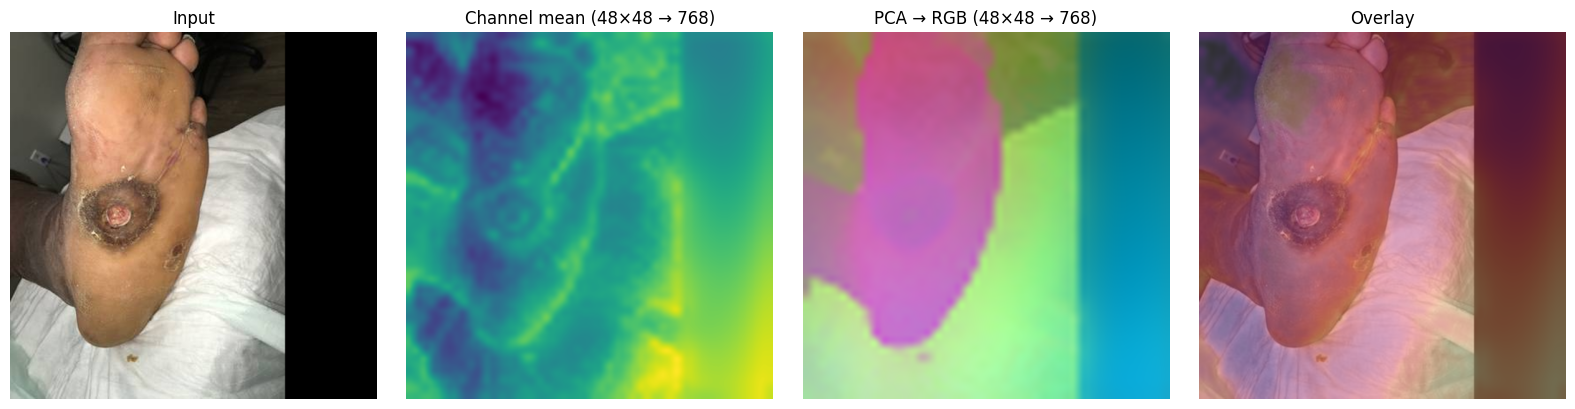

In [9]:
def feature_channel_mean(features: torch.Tensor) -> np.ndarray:
    """[B, C, H, W] → [H, W] numpy heatmap."""
    return features[0].mean(dim=0).detach().cpu().numpy()


def feature_pca_rgb(features: torch.Tensor, n_components: int = 3) -> np.ndarray:
    """[B, C, H, W] → [H, W, 3] numpy RGB (0~1)."""
    _, channels, height, width = features.shape
    flat = features[0].permute(1, 2, 0).reshape(-1, channels).detach().cpu()
    _, _, basis = torch.pca_lowrank(flat, q=n_components)
    projected = flat @ basis[:, :n_components]
    rgb = projected.reshape(height, width, n_components).numpy()
    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-6)
    return rgb


def upsample_map(values: np.ndarray, size: int) -> np.ndarray:
    """[H, W] → [size, size] bicubic upsample for display."""
    tensor = torch.from_numpy(values).float().unsqueeze(0).unsqueeze(0)
    up = F.interpolate(tensor, size=(size, size), mode="bicubic", align_corners=False)
    return up.squeeze().numpy()


def upsample_rgb(rgb: np.ndarray, size: int) -> np.ndarray:
    """[H, W, 3] → [size, size, 3] bicubic upsample."""
    tensor = torch.from_numpy(rgb).float().permute(2, 0, 1).unsqueeze(0)
    up = F.interpolate(tensor, size=(size, size), mode="bicubic", align_corners=False)
    return up.squeeze(0).permute(1, 2, 0).numpy()


def overlay_heatmap(
    image: Image.Image,
    heatmap: np.ndarray,
    alpha: float = 0.45,
    target_size: int | None = None,
) -> np.ndarray:
    size = target_size or DISPLAY_SIZE
    resized = image.resize((size, size), Image.Resampling.BILINEAR)
    base = np.asarray(resized, dtype=np.float32) / 255.0
    heat_up = upsample_map(heatmap, size)
    heat_up = (heat_up - heat_up.min()) / (heat_up.max() - heat_up.min() + 1e-6)
    heat_color = plt.get_cmap("magma")(heat_up)[..., :3]
    return np.clip((1 - alpha) * base + alpha * heat_color, 0.0, 1.0)


grid = features.shape[-1]
mean_map = feature_channel_mean(features)
pca_rgb = feature_pca_rgb(features)
mean_display = upsample_map(mean_map, DISPLAY_SIZE)
pca_display = upsample_rgb(pca_rgb, DISPLAY_SIZE)
overlay = overlay_heatmap(image, mean_map)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(image)
axes[0].set_title("Input")
axes[1].imshow(mean_display, cmap="viridis")
axes[1].set_title(f"Channel mean ({grid}×{grid} → {DISPLAY_SIZE})")
axes[2].imshow(pca_display)
axes[2].set_title(f"PCA → RGB ({grid}×{grid} → {DISPLAY_SIZE})")
axes[3].imshow(overlay)
axes[3].set_title("Overlay")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## 3. (선택) cache_features.py 로 저장된 shard 읽기

먼저 캐시를 만들려면 터미널에서:

```bash
python cache_features.py --task foot --split train --image-size 384 --run-name demo --limit-batches 2
```

In [10]:
def find_feature_cache_dir() -> Path | None:
    if not FEATURE_CACHE_DIR.exists():
        return None
    runs = sorted(p for p in FEATURE_CACHE_DIR.iterdir() if p.is_dir())
    return runs[-1] if runs else None


cache_dir = find_feature_cache_dir()
if cache_dir is None:
    print(f"feature cache 없음: {FEATURE_CACHE_DIR}")
    print("위 markdown 셀의 cache_features.py 명령으로 먼저 생성하세요.")
else:
    shard_path = cache_dir / "foot" / "train" / "shard_00000.pt"
    manifest_path = cache_dir / "foot" / "train" / "manifest.json"

    if not shard_path.exists():
        print(f"shard 없음: {shard_path}")
    else:
        shard = torch.load(shard_path, map_location="cpu", weights_only=True)
        print(f"cache run: {cache_dir.name}")
        print(f"keys:      {list(shard.keys())}")
        print(f"features:  {tuple(shard['features'].shape)} dtype={shard['features'].dtype}")
        print(f"sample 0:  {shard['image_paths'][0]}")

        if manifest_path.exists():
            import json

            manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
            print(f"manifest:  count={manifest['count']} feature_shape={manifest['feature_shape']}")

        cached_feat = shard["features"][0].unsqueeze(0).float()
        cached_mean = feature_channel_mean(cached_feat)

        plt.figure(figsize=(4, 4))
        plt.imshow(cached_mean, cmap="viridis")
        plt.title("Cached feature (channel mean)")
        plt.axis("off")
        plt.show()

feature cache 없음: /mnt/d/ysla/01_Work/02_당뇨발/01_개발/dfu-project/output/feature_cache
위 markdown 셀의 cache_features.py 명령으로 먼저 생성하세요.


## 4. (선택) feature tensor 저장

다른 스크립트에서 재사용하려면 `.pt` 로 저장할 수 있습니다.

In [11]:
OUT_DIR = PROJECT_ROOT / "output" / "example_features"
OUT_DIR.mkdir(parents=True, exist_ok=True)

out_path = OUT_DIR / f"{IMAGE_PATH.stem}_backbone_feat.pt"
torch.save(
    {
        "features": features.detach().cpu(),
        "image_path": str(IMAGE_PATH),
        "image_size": IMAGE_SIZE,
        "checkpoint": str(CHECKPOINT),
    },
    out_path,
)
print(f"saved: {out_path}")

saved: /mnt/d/ysla/01_Work/02_당뇨발/01_개발/dfu-project/output/example_features/Diabetic Foot Ulcer 1_backbone_feat.pt
